In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import wisardpkg as wp

In [2]:
DATASET_DIR = "dataset_omr_limpo"

IMG_SIZE = (32, 32)

THRESHOLD = 127

In [3]:
def mostrar(img, titulo="", cmap="gray"):

    plt.figure(figsize=(4,4))

    plt.imshow(img, cmap=cmap)

    plt.title(titulo)

    plt.axis("off")

    plt.show()

In [4]:
def processar_imagem(caminho_img):

    # =====================================================
    # 1. ORIGINAL
    # =====================================================

    original = cv2.imread(caminho_img)

    original_rgb = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    mostrar(original_rgb, "Imagem Original", cmap=None)

    # =====================================================
    # 2. ESCALA DE CINZA
    # =====================================================

    gray = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2GRAY
    )

    mostrar(gray, "Escala de Cinza")

    # =====================================================
    # 3. RESIZE
    # =====================================================

    resized = cv2.resize(
        gray,
        IMG_SIZE
    )

    mostrar(resized, "Resize 32x32")

    # =====================================================
    # 4. BINARIZAÇÃO
    # =====================================================

    _, binary = cv2.threshold(
        resized,
        THRESHOLD,
        255,
        cv2.THRESH_BINARY_INV
    )

    mostrar(binary, "Imagem Binária")

    # =====================================================
    # 5. FLATTEN
    # =====================================================

    vetor = binary.flatten()

    vetor_binario = (vetor > 0).astype(np.uint8)

    print("Tamanho do vetor:", len(vetor_binario))

    print("\nPrimeiros 100 valores:\n")

    print(vetor_binario[:100])

    # =====================================================
    # 6. RECONSTRUÇÃO
    # =====================================================

    reconstruida = vetor_binario.reshape(32, 32)

    mostrar(reconstruida, "Reconstruída do Vetor")

    return vetor_binario

In [5]:
# pega automaticamente a primeira imagem encontrada

for classe in os.listdir(DATASET_DIR):

    pasta = os.path.join(DATASET_DIR, classe)

    if not os.path.isdir(pasta):
        continue

    arquivos = os.listdir(pasta)

    if len(arquivos) > 0:

        caminho_exemplo = os.path.join(
            pasta,
            arquivos[0]
        )

        classe_exemplo = classe

        break

print("Classe:", classe_exemplo)

print("Arquivo:", caminho_exemplo)

Classe: note-A2_double_whole.
Arquivo: dataset_omr_limpo/note-A2_double_whole./211002611-1_1_1_0007.png


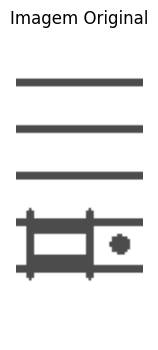

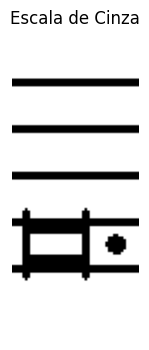

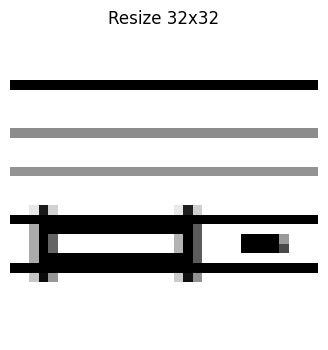

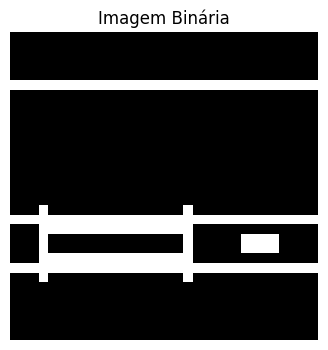

Tamanho do vetor: 1024

Primeiros 100 valores:

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


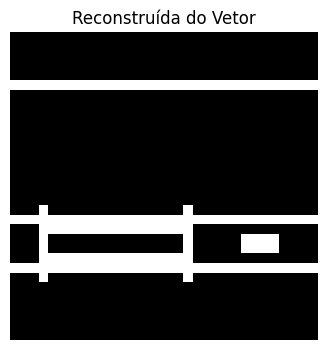

In [6]:
vetor_exemplo = processar_imagem(caminho_exemplo)

In [7]:
def carregar_dataset(dataset_dir):

    X = []
    y = []

    classes = sorted(os.listdir(dataset_dir))

    for classe in classes:

        caminho_classe = os.path.join(
            dataset_dir,
            classe
        )

        if not os.path.isdir(caminho_classe):
            continue

        print(f"Lendo: {classe}")

        for arquivo in os.listdir(caminho_classe):

            if not arquivo.lower().endswith(".png"):
                continue

            caminho_img = os.path.join(
                caminho_classe,
                arquivo
            )

            img = cv2.imread(
                caminho_img,
                cv2.IMREAD_GRAYSCALE
            )

            if img is None:
                continue

            img = cv2.resize(
                img,
                IMG_SIZE
            )

            _, img_bin = cv2.threshold(
                img,
                THRESHOLD,
                255,
                cv2.THRESH_BINARY_INV
            )

            vetor = img_bin.flatten()

            vetor = (vetor > 0).astype(np.uint8)

            X.append(vetor)

            y.append(classe)

    return np.array(X), np.array(y)

In [8]:
X, y = carregar_dataset(DATASET_DIR)

print("\nFormato X:", X.shape)

print("Formato y:", y.shape)

Lendo: barline


Lendo: clef-C1
Lendo: clef-C2
Lendo: clef-C3
Lendo: clef-C4
Lendo: clef-F3
Lendo: clef-F4
Lendo: clef-G1
Lendo: clef-G2
Lendo: gracenote-A#4_eighth
Lendo: gracenote-A#4_half
Lendo: gracenote-A3_eighth
Lendo: gracenote-A3_quarter
Lendo: gracenote-A3_sixteenth
Lendo: gracenote-A4_eighth
Lendo: gracenote-A4_half
Lendo: gracenote-A4_quarter
Lendo: gracenote-A4_sixteenth
Lendo: gracenote-A4_thirty_second
Lendo: gracenote-Ab3_eighth
Lendo: gracenote-Ab3_thirty_second
Lendo: gracenote-Ab4_eighth
Lendo: gracenote-Ab4_quarter
Lendo: gracenote-Ab4_sixteenth
Lendo: gracenote-Ab5_eighth
Lendo: gracenote-B3_eighth
Lendo: gracenote-B4_eighth
Lendo: gracenote-B4_quarter
Lendo: gracenote-B4_sixteenth
Lendo: gracenote-B4_thirty_second
Lendo: gracenote-Bb3_eighth
Lendo: gracenote-Bb3_quarter
Lendo: gracenote-Bb3_sixteenth
Lendo: gracenote-Bb3_thirty_second
Lendo: gracenote-Bb4_eighth
Lendo: gracenote-Bb4_half
Lendo: gracenote-Bb4_quarter
Lendo: gracenote-Bb4_sixteenth
Lendo: gracenote-Bb4_thirty_second


In [9]:
from collections import Counter
from sklearn.model_selection import train_test_split

# =========================================================
# REMOVE CLASSES COM MENOS DE 2 EXEMPLOS
# =========================================================

contagem = Counter(y)

classes_validas = {
    classe
    for classe, qtd in contagem.items()
    if qtd >= 2
}

X_filtrado = []
y_filtrado = []

for xi, yi in zip(X, y):

    if yi in classes_validas:

        X_filtrado.append(xi)
        y_filtrado.append(yi)

X_filtrado = np.array(X_filtrado)
y_filtrado = np.array(y_filtrado)

print("Dataset original:", len(y))
print("Dataset filtrado:", len(y_filtrado))

Dataset original: 200555
Dataset filtrado: 200364


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_filtrado,
    y_filtrado,
    test_size=0.2,
    random_state=42,
    stratify=y_filtrado
)

print("Treino:", X_train.shape)

print("Teste :", X_test.shape)

Treino: (160291, 1024)
Teste : (40073, 1024)


In [11]:
addressSize = 16
minScore = 0.5
threshold = 20
discriminatorLimit = 10

wsd = wp.ClusWisard(addressSize, minScore, threshold, discriminatorLimit)

print("WiSARD criada!")

WiSARD criada!


In [12]:
wsd.train(
    X_train.tolist(),
    y_train.tolist()
)

print("Treinamento finalizado!")

Treinamento finalizado!


In [13]:
saida = wsd.classify(
    X_test.tolist()
)

acertos = np.sum(
    np.array(saida) == y_test
)

acc = acertos / len(y_test)

print(f"\nAcurácia: {acc:.4f}")


Acurácia: 0.8289


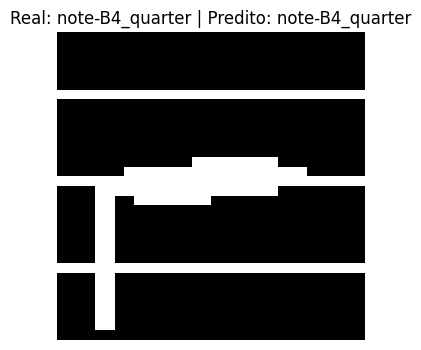

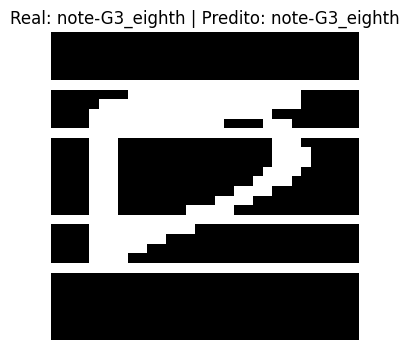

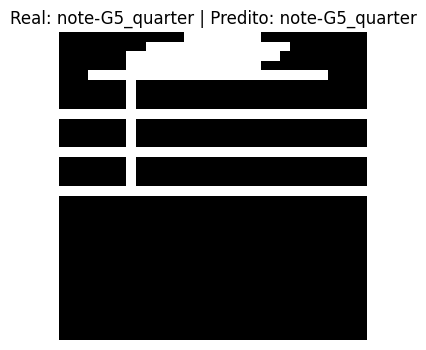

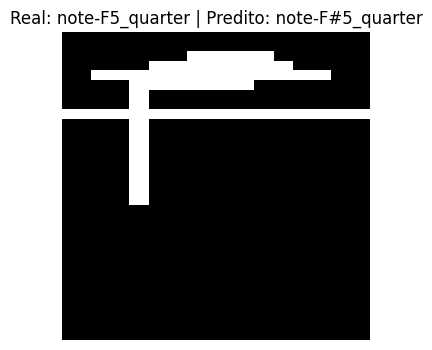

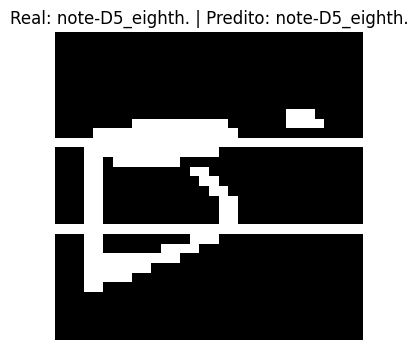

In [14]:
for i in range(5):

    img = X_test[i].reshape(32, 32)

    mostrar(img, f"Real: {y_test[i]} | Predito: {saida[i]}")